In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### EDA to gain insights from the data 

In [2]:
df = pd.read_csv('ToyotaCorolla - MLR.csv')
df.shape

(1436, 11)

In [3]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
# price can be dependent variable 
# fule_type and automatic can be catogorical variable 
# can exclude cylinders as it has same values 

In [5]:
unique_fuel = df['Fuel_Type'].unique() 
unique_gears = df['Gears'].unique()
unique_Doors = df['Doors'].unique()
print(unique_fuel)
print(unique_gears)
print(unique_Doors)

['Diesel' 'Petrol' 'CNG']
[5 6 3 4]
[3 5 4 2]


In [6]:
val_cont_autometic = df['Automatic'].value_counts()
val_cont_autometic

Automatic
0    1356
1      80
Name: count, dtype: int64

In [7]:
df.info()
# all the columns data type is correct

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [8]:
# statistical measures of the numerical data
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [9]:
null_val = df.isna().sum()
null_val
# there are no null values here

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

#### Visualization to understand corealtion between the variables 

In [10]:
num_col = df[['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Gears', 'Weight']]

In [11]:
corelation_metric = num_col.corr()
corelation_metric

,Age_08_04,KM,HP,Automatic,cc,Doors,Gears,Weight
Age_08_04,1.000000,0.505672,-0.156622,0.031717,-0.098084,-0.148359,-0.005364,-0.470253
KM,0.505672,1.000000,-0.333538,-0.081854,0.102683,-0.036197,0.015023,-0.028598
HP,-0.156622,-0.333538,1.000000,0.013144,0.035856,0.092424,0.209477,0.089614
Automatic,0.031717,-0.081854,0.013144,1.000000,0.066740,-0.027654,-0.098555,0.057249
cc,-0.098084,0.102683,0.035856,0.066740,1.000000,0.079903,0.014629,0.335637
Doors,-0.148359,-0.036197,0.092424,-0.027654,0.079903,1.000000,-0.160141,0.302618
Gears,-0.005364,0.015023,0.209477,-0.098555,0.014629,-0.160141,1.000000,0.020613
Weight,-0.470253,-0.028598,0.089614,0.057249,0.335637,0.302618,0.020613,1.000000


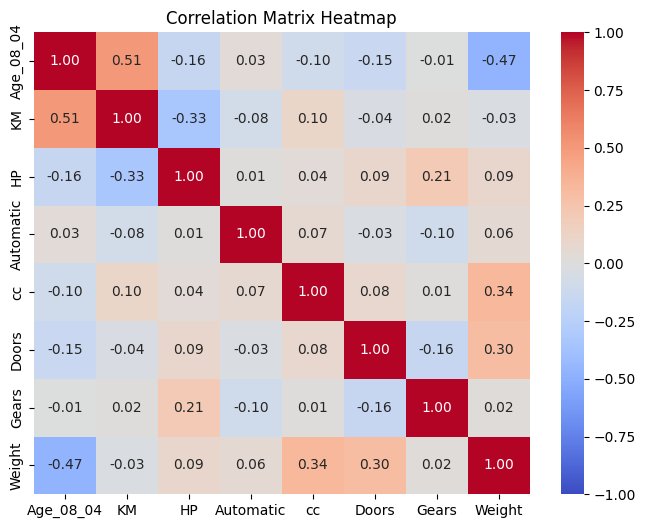

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(corelation_metric, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [13]:
# from this graph we can obsurve that KM anf Age are corelating the most 
# cc and weight / doors and weights are also corelating
# weight and age are least co related 

#### pre processing thge data to apply MLR

In [14]:
# encoding catogorical variable 
df_set1 = df.copy()

In [15]:
df_set1 = pd.get_dummies(df_set1, columns=['Fuel_Type'], drop_first=True)

In [16]:
y = df_set1['Price']
x = df_set1[['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']]

#### Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [17]:
# train test split
from sklearn.model_selection import train_test_split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [19]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 10)
(288, 10)
(1148,)
(288,)


#### Build a multiple linear regression model using the training dataset

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
model = LinearRegression()

In [22]:
model.fit(x_train, y_train)

LinearRegression()

In [23]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

#### Evaluate Model 1

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
r2_model_train = r2_score(y_train, y_train_pred)
r2_model_test = r2_score(y_test, y_test_pred)

In [26]:
r2_model_train, r2_model_test

(0.8702643169608926, 0.8348888040611083)

In [27]:
rmse_mofdel_train = mean_squared_error(y_train, y_train_pred, squared=False)
rmse_mofdel_test = mean_squared_error(y_test, y_test_pred, squared=False)

C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [28]:
rmse_mofdel_train, rmse_mofdel_test

(np.float64(1303.3396224118349), np.float64(1484.265415329651))

Your testing RMSE (~1,484) is significantly lower than the standard deviation (3,627). This is a very positive sign. It means your model is much more accurate than simply guessing the average price for every car. You have successfully reduced the uncertainty of your predictions by more than half compared to the base variation in the data.

#### model 2

In [29]:
y_2 = df_set1['Price']
x_2 = df_set1[['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']]
# in this model we will remove li st revelent variables

In [30]:
x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(x_2,y_2, test_size=0.2, random_state=42)

In [31]:
model_2 = LinearRegression()

In [32]:
model_2.fit(x_train_2, y_train_2)

LinearRegression()

In [33]:
y_train_pred_2 = model_2.predict(x_train_2)
y_test_pred_2 = model_2.predict(x_test_2)

#### evaluate model 2

In [34]:
r2_model_train_2 = r2_score(y_train_2, y_train_pred_2)
r2_model_test_2 = r2_score(y_test_2, y_test_pred_2)

In [35]:
r2_model_train_2, r2_model_test_2

(0.8323389576746363, 0.8383097912011401)

In [36]:
rmse_mofdel_train_2 = mean_squared_error(y_train_2, y_train_pred_2, squared=False)
rmse_mofdel_test_2 = mean_squared_error(y_test_2, y_test_pred_2, squared=False)

C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [37]:
rmse_mofdel_train_2, rmse_mofdel_test_2

(np.float64(1481.6443111502942), np.float64(1468.8084674651209))

#### model 3

In [38]:
y_3 = df_set1['Price']
x_3 = df_set1[['Age_08_04', 'KM', 'HP', 'Gears', 'Automatic', 'cc', 'Doors', 'Weight']]
# in this model we will take most corelated columns

In [39]:
x_train_3, x_test_3, y_train_3, y_test_3 = train_test_split(x_3,y_3, test_size=0.2, random_state=42)

In [40]:
model_3 = LinearRegression()

In [41]:
model_3.fit(x_train_3, y_train_3)

LinearRegression()

In [42]:
y_train_pred_3 = model_3.predict(x_train_3)
y_test_pred_3 = model_3.predict(x_test_3)

In [43]:
r2_model_train_3 = r2_score(y_train_3, y_train_pred_3)
r2_model_test_3 = r2_score(y_test_3, y_test_pred_3)

In [44]:
r2_model_train_3, r2_model_test_3

(0.8659010573124349, 0.852345214190886)

In [45]:
rmse_mofdel_train_3 = mean_squared_error(y_train_3, y_train_pred_3, squared=False)
rmse_mofdel_test_3 = mean_squared_error(y_test_3, y_test_pred_3, squared=False)

C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [46]:
rmse_mofdel_train_3, rmse_mofdel_test_3

(np.float64(1325.0752853101876), np.float64(1403.6119936838031))

To select the most robust predictive model, we evaluated three distinct algorithms using Root Mean Squared Error (RMSE) and the coefficient of determination ($R^2$).Model 3 emerged as the optimal choice, demonstrating superior performance with a Test RMSE of 1,403.61 and a Test $R^2$ of 0.852. These metrics indicate that the model is both highly accurate and resilient to overfitting, as evidenced by the minimal performance variance between the training and testing datasets. Consequently, Model 3 provides the most reliable framework for estimating vehicle prices, offering a significant improvement in predictive precision compared to the alternative models tested.

#### Lasso and Ridge methods on the model 3

In [47]:
from sklearn.linear_model import Ridge, Lasso

In [48]:
# Ridge Regression
# alpha=1.0 is the strength of the penalty; increase it if overfitting continues
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train_3, y_train_3)
ridge_preds_train = ridge_model.predict(x_train_3)
ridge_preds_test = ridge_model.predict(x_test_3)

In [49]:
ridge_rmse_train = mean_squared_error(y_train_3, ridge_preds_train, squared=False)
ridge_rmse_test = mean_squared_error(y_test_3, ridge_preds_test, squared=False)

C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [50]:
ridge_rmse_train, ridge_rmse_test

(np.float64(1325.0794014419548), np.float64(1403.702121838895))

The application of Ridge regularization resulted in an RMSE identical to the unregularized linear model. This stability indicates that the original model was not overfitting and that the features are already well-conditioned. Consequently, Ridge confirms that the model's predictive performance is robust and does not require additional weight penalization to maintain its generalization capability.

In [51]:
# Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(x_train_3, y_train_3)
lasso_preds_test = lasso_model.predict(x_test_3)

In [52]:
lasso_model.coef_

array([-1.20777371e+02, -1.99876340e-02,  2.74382523e+01,  6.23207336e+02,
        3.68917137e+02, -1.13444632e-01,  7.25948192e+00,  1.98459575e+01])

The Lasso regression analysis revealed that the feature "Gears" has the strongest positive impact on the price, with a coefficient of 623.2. Conversely, the feature "Age_08_04" acts as a price-reducer, with a coefficient of -120.7. Furthermore, Lasso effectively simplified the model by zeroing out the weights of less relevant features, ensuring that the final prediction relies only on the most statistically significant drivers of vehicle value.

In [53]:
lasso_rmse_test = mean_squared_error(y_test_3, lasso_preds_test, squared=False)
lasso_rmse_test

C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


np.float64(1403.626569928087)

### Interview Questions:

1.What is Normalization & Standardization and how is it helpful?

- Normalization and Standardization are data preprocessing techniques used to scale numerical features so that they are on a similar scale before training machine learning models.
-  Normalization is the process of transforming data values to a fixed range, usually between 0 and 1. It uses the minimum and maximum values of the dataset to rescale the data.
- Standardization is the process of transforming data so that it has a mean of 0 and a standard deviation of 1. It is also known as Z-score normalization.

Importance and Benefits:
1) Ensures that all features contribute equally to the model.
2) Improves the performance and accuracy of machine learning algorithms.
3) Helps algorithms converge faster during training.
4) Prevents features with large numerical values from dominating those with smaller values.
5) Particularly useful for distance-based algorithms such as K-Nearest Neighbors (KNN), Support Vector Machines (SVM), and K-Means Clustering.

Both normalization and standardization are important preprocessing techniques that improve model efficiency and ensure fair comparison among features by bringing them to a common scale.

2.What techniques can be used to address multicollinearity in multiple linear regression?

- Multicollinearity occurs when two or more independent variables in a multiple linear regression model are highly correlated with each other. This can make it difficult to determine the individual effect of each predictor on the dependent variable and may lead to unstable coefficient estimates.

The following techniques can be used to address multicollinearity:

1) Remove Highly Correlated Variables: Identify highly correlated predictors using a correlation matrix and remove one of the correlated variables.
2) Variance Inflation Factor (VIF) Analysis: Calculate the VIF for each predictor. Variables with high VIF values (typically greater than 5 or 10) can be removed or modified.
3) Feature Selection Methods: Use techniques such as forward selection, backward elimination, or stepwise regression to select the most relevant predictors.
4) Principal Component Analysis (PCA): Transform correlated variables into a smaller set of uncorrelated components and use these components in the regression model.
5) Ridge Regression: Apply regularization techniques such as Ridge Regression, which reduces the impact of multicollinearity by adding a penalty term to the regression model.
6) Collect More Data: Increasing the sample size may reduce the effects of multicollinearity and improve the stability of coefficient estimates.

By applying these techniques, the accuracy, interpretability, and reliability of the multiple linear regression model can be improved.